In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pima-indians-diabetes-database/diabetes.csv


# This notebook is a demonstration on using custom-activation function with Keras Tuner to build an ANN. My goal here is not to make the best possible result, but just what I can manage with above mentioned implementation.

In [2]:
# Loading the data
df = pd.read_csv('/kaggle/input/pima-indians-diabetes-database/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
# Now I had this insight from other notebooks that the outcome vals (0 & 1) are imbalanced, as you can see below

df['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

Since we know that the outcome is imbalanced, we can try and make a balanced dataset using over-sampling, under-sampling or SMOTE etc. I will stick with over-sampling.

In [5]:
# Seperating the target column
y = df.pop('Outcome').values
X = df.iloc[:,:].values

In [6]:
from imblearn.over_sampling import RandomOverSampler
X, y = RandomOverSampler().fit_resample(X, y)

In [7]:
# Assuming data come from same distribution, we can Scale and Split data into train & test sets

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [8]:
# Importing Libraries

import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Dropout
import matplotlib.pyplot as plt

Making a custom activation function. This is the easiest way to make one of your own. Else you may need to write the python -
-function for the avtivation function, vectorize it, define its derivative and use gradient tape. But if you could write the 
function as a tensorflow function, tensorflow can automatically take care of the rest.

In this case, let's say I want to make the |x| function as the activation function. But as we know this function is is not differentiable at 0, So I substituted a modified sine function to replace the graph of |x| in the interval (-1.6891, 1.6892). For rest of the interval the function remains |x|. This is may not be a good function, but we are just interested in the implementation.

If I had to write a python function, I could use an if-else to execute it easily. But it gets much complicated in tensorflow. May be experts can, but I found it very challenging. So I resorted to multiplying the |x| and sine part of activation function with a floor-division such that in the desired interval only one function holds true

In [9]:
# defining the activation function in tensorflow

import tensorflow as tf

def custom_activation(x):
  
  pi = tf.constant(np.pi)
  a = 1.5*pi
  b = tf.multiply(tf.math.floordiv(1.6892,tf.abs(x)), tf.add(tf.sin(tf.add(tf.multiply(1.380050139, x), a)),1)) 
  c = tf.multiply(tf.subtract(1.0, tf.math.floordiv(1.6892,tf.abs(x))), tf.abs(x))
  d = tf.add(b, c)

  return d



In [10]:
# defining another activation function (x=x, basically returning itself) in tensorflow

import tensorflow as tf

def custom_activation1(x):

  return x

In [11]:
#Installing keras_tuner

!pip install -U keras-tuner

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 590.7 kB/s eta 0:00:00
  Attempting uninstall: keras-tuner
    Found existing installation: keras-tuner 1.1.2
    Uninstalling keras-tuner-1.1.2:
      Successfully uninstalled keras-tuner-1.1.2


In [12]:
import keras_tuner as kt

Now, if you wanted to use the custom activation direcly by making model architecture manually, you can use the function directly into the activation parameter in model.add(). But it won't work in keras-tuner. We have to make a dictionary of custom objects, with its name as the dictionary key, and pass this dictionary as input to keras.utils.custom_object_scope to define the model.

In [13]:
def build_model(hp):

  model = Sequential()

  counter = 0

  for i in range(hp.Int('numlayers', min_value=1, max_value=10)):

    if counter == 0:

      custom_objects = {"custom_activation": custom_activation,'custom_activation1': custom_activation1}

      with keras.utils.custom_object_scope(custom_objects):
        model.add(Dense(hp.Int('units'+str(i), min_value=8, max_value=128, step=8),
                      activation=hp.Choice('activation'+str(i), values=['relu', 'tanh', 'sigmoid','custom_activation','custom_activation1']),
                      input_dim=X.shape[1]))
        model.add(Dropout(hp.Choice('dropout'+str(i), values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
      
      counter += 1
    else:
      
      custom_objects = {"custom_activation": custom_activation,'custom_activation1': custom_activation1}

      with keras.utils.custom_object_scope(custom_objects):
        model.add(Dense(hp.Int('units'+str(i), min_value=8, max_value=128, step=8),
                      activation=hp.Choice('activation'+str(i), values=['relu', 'tanh', 'sigmoid', 'custom_activation','custom_activation1']),
                      ))
        model.add(Dropout(hp.Choice('dropout'+str(i), values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
      
    


  model.add(Dense(1, activation='sigmoid'))

  model.compile(optimizer=hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop','nadam', 'adadelta']), loss='binary_crossentropy', metrics=['accuracy'])

  return model

Once the build model is defined, you can use one of the 4 algorithms to search for the best model architecture (Sklearn,Randomsearch, Bayesian Optimization & Hyperband) Let's see Hyperband first

In [14]:
tuner = kt.Hyperband(build_model, objective='val_accuracy', directory='mydir', project_name='custom')

2022-10-31 20:48:00.135220: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [15]:
# Search for the best model.

tuner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Trial 254 Complete [00h 00m 22s]
val_accuracy: 0.6200000047683716

Best val_accuracy So Far: 0.8050000071525574
Total elapsed time: 00h 11m 06s


In [16]:
# Look at the best hyperparameter combination

tuner.get_best_hyperparameters()[0].values

{'numlayers': 6,
 'units0': 16,
 'activation0': 'relu',
 'dropout0': 0.1,
 'optimizer': 'adam',
 'units1': 80,
 'activation1': 'tanh',
 'dropout1': 0.6,
 'units2': 104,
 'activation2': 'tanh',
 'dropout2': 0.5,
 'units3': 56,
 'activation3': 'custom_activation1',
 'dropout3': 0.4,
 'units4': 120,
 'activation4': 'tanh',
 'dropout4': 0.3,
 'units5': 56,
 'activation5': 'relu',
 'dropout5': 0.2,
 'units6': 24,
 'activation6': 'sigmoid',
 'dropout6': 0.5,
 'units7': 88,
 'activation7': 'tanh',
 'dropout7': 0.8,
 'units8': 120,
 'activation8': 'relu',
 'dropout8': 0.3,
 'tuner/epochs': 2,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 4,
 'tuner/round': 0}

We see that kt suggest a model of 2 layers with optimizer' being 'nadam' & activations 'tanh' & 'relu' for the 1st and 2nd layers. Let's retrieve and train this model

In [17]:
model1 = tuner.get_best_models(num_models=1)[0]

In [18]:
history1 = model1.fit(X_train,y_train,batch_size=32,epochs=20, initial_epoch=0, validation_data=(X_test,y_test))

Epoch 1/20
25/25 [==============================] - 1s 12ms/step - loss: 0.5748 - accuracy: 0.7063 - val_loss: 0.4842 - val_accuracy: 0.7950
Epoch 2/20
25/25 [==============================] - 0s 6ms/step - loss: 0.5685 - accuracy: 0.7038 - val_loss: 0.4850 - val_accuracy: 0.8000
Epoch 3/20
25/25 [==============================] - 0s 6ms/step - loss: 0.5616 - accuracy: 0.7237 - val_loss: 0.4798 - val_accuracy: 0.7950
Epoch 4/20
25/25 [==============================] - 0s 6ms/step - loss: 0.5683 - accuracy: 0.7237 - val_loss: 0.4907 - val_accuracy: 0.7950
Epoch 5/20
25/25 [==============================] - 0s 7ms/step - loss: 0.5394 - accuracy: 0.7237 - val_loss: 0.4807 - val_accuracy: 0.8000
Epoch 6/20
25/25 [==============================] - 0s 7ms/step - loss: 0.5396 - accuracy: 0.7362 - val_loss: 0.4854 - val_accuracy: 0.7900
Epoch 7/20
25/25 [==============================] - 0s 6ms/step - loss: 0.5412 - accuracy: 0.7350 - val_loss: 0.4749 - val_accuracy: 0.7950
Epoch 8/20
25/25 [=

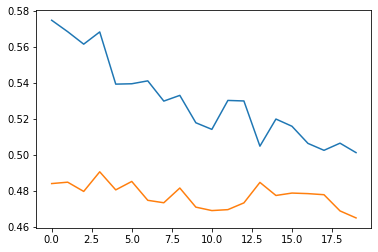

In [19]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [20]:
# Since our model did not have our custom activation functions, let's try another algorithm i.e Randomsearch. Make sure to 
# change the project_name.

In [21]:
tuner = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=50, directory='mydir', project_name='custom5') 

In [22]:
tuner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Trial 50 Complete [00h 00m 02s]
val_accuracy: 0.5

Best val_accuracy So Far: 0.7900000214576721
Total elapsed time: 00h 01m 41s


In [23]:
tuner.get_best_hyperparameters()[0].values

{'numlayers': 2,
 'units0': 96,
 'activation0': 'custom_activation1',
 'dropout0': 0.8,
 'optimizer': 'adam',
 'units1': 112,
 'activation1': 'custom_activation1',
 'dropout1': 0.4,
 'units2': 40,
 'activation2': 'custom_activation1',
 'dropout2': 0.7,
 'units3': 48,
 'activation3': 'relu',
 'dropout3': 0.1,
 'units4': 16,
 'activation4': 'custom_activation',
 'dropout4': 0.4,
 'units5': 64,
 'activation5': 'sigmoid',
 'dropout5': 0.1,
 'units6': 16,
 'activation6': 'custom_activation1',
 'dropout6': 0.1,
 'units7': 16,
 'activation7': 'sigmoid',
 'dropout7': 0.8,
 'units8': 104,
 'activation8': 'sigmoid',
 'dropout8': 0.8,
 'units9': 112,
 'activation9': 'tanh',
 'dropout9': 0.2}

one of our custom activation function figures in the best model returned by KT (2nd Layer). Let's train it

In [24]:
model2 = tuner.get_best_models(num_models=1)[0]
model2.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 96)                864       
_________________________________________________________________
dropout (Dropout)            (None, 96)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 112)               10864     
_________________________________________________________________
dropout_1 (Dropout)          (None, 112)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 113       
Total params: 11,841
Trainable params: 11,841
Non-trainable params: 0
_________________________________________________________________


In [25]:
# We already trained this model while kt was searching for optimal hyperparameters until 5th epoch. Continuing from there(initial_epoch=5)
history2 = model2.fit(X_train,y_train,batch_size=16,epochs=30, initial_epoch=0, validation_data=(X_test,y_test))

Epoch 1/30
50/50 [==============================] - 1s 6ms/step - loss: 0.6118 - accuracy: 0.7113 - val_loss: 0.5053 - val_accuracy: 0.7900
Epoch 2/30
50/50 [==============================] - 0s 3ms/step - loss: 0.6000 - accuracy: 0.7300 - val_loss: 0.4935 - val_accuracy: 0.7800
Epoch 3/30
50/50 [==============================] - 0s 3ms/step - loss: 0.5847 - accuracy: 0.7163 - val_loss: 0.4975 - val_accuracy: 0.7900
Epoch 4/30
50/50 [==============================] - 0s 3ms/step - loss: 0.5996 - accuracy: 0.7300 - val_loss: 0.5025 - val_accuracy: 0.7850
Epoch 5/30
50/50 [==============================] - 0s 4ms/step - loss: 0.5592 - accuracy: 0.7312 - val_loss: 0.5012 - val_accuracy: 0.7900
Epoch 6/30
50/50 [==============================] - 0s 3ms/step - loss: 0.5721 - accuracy: 0.7200 - val_loss: 0.4937 - val_accuracy: 0.7800
Epoch 7/30
50/50 [==============================] - 0s 3ms/step - loss: 0.5661 - accuracy: 0.7075 - val_loss: 0.4968 - val_accuracy: 0.7700
Epoch 8/30
50/50 [==

In [26]:
# Predicting on test set

y_pred2 = model2.predict(X_test)
y_pred2[y_pred2>0.5] = 1
y_pred2[y_pred2<0.5] = 0
y_pred2 = y_pred2.astype('int')

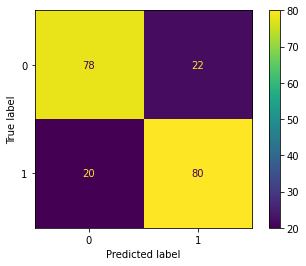

In [27]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(cm)
disp.plot()